Veri yükleniyor...
Anomali analizi için veri hazırlanıyor...
-> Isolation Forest Modeli: 199 adet şüpheli işlem tespit etti.
-> Local Outlier Factor Modeli: 200 adet şüpheli işlem tespit etti.


C:\Users\uygrg\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


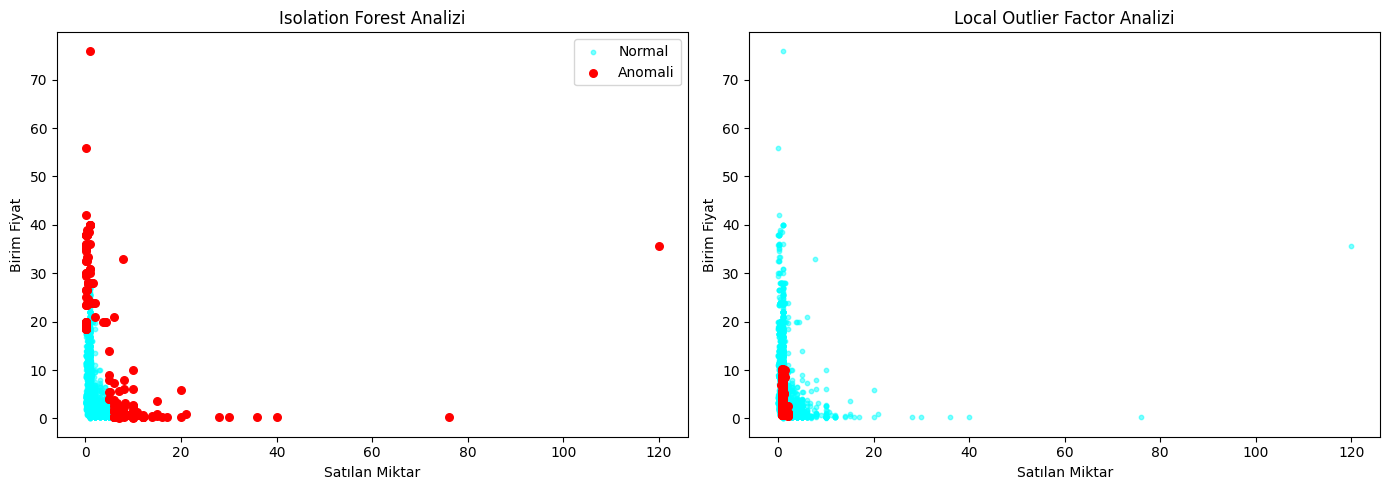


--- TESPİT EDİLEN BAZI ŞÜPHELİ İŞLEMLER (ÖRNEK) ---
        PRICE  AMOUNT
37595     3.5   1.070
565353    4.5   0.926
69077     0.8   1.220
210835    3.1   1.055
418304    9.0   1.082


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# --- 1. VERİ KONTROLÜ (Dosya yüklü mü?) ---
if 'df' not in locals():
    print("Veri yükleniyor...")
    olasi_yollar = ['MarketSales.xlsx', 'MarketSales.csv', '../MarketSales.xlsx', '../MarketSales.csv']
    for yol in olasi_yollar:
        if os.path.exists(yol):
            try:
                df = pd.read_excel(yol) if yol.endswith('xlsx') else pd.read_csv(yol)
                break
            except: continue

# --- 2. VERİ HAZIRLIĞI ---
print("Anomali analizi için veri hazırlanıyor...")

# Sadece Fiyat (PRICE) ve Miktar (AMOUNT) sütunlarına odaklanıyoruz
# Anomali tespiti görselleştirme için 10.000 satırlık örneklem alıyoruz
df_ano = df[['PRICE', 'AMOUNT']].dropna().sample(n=10000, random_state=42)

# Ölçeklendirme (Anomali tespitinde verilerin aynı aralıkta olması şarttır)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ano)

# --- 3. MODELLEME (AUTOML MANTIĞI: 2 FARKLI ALGORİTMA) ---
# Tek bir modele güvenmemek için Ensemble (Topluluk) yaklaşımı kullanıyoruz.

models = {
    "Isolation Forest": IsolationForest(contamination=0.02, random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, contamination=0.02)
}

# --- 4. SONUÇLARI GÖRSELLEŞTİRME ---
plt.figure(figsize=(14, 5))

for i, (name, model) in enumerate(models.items()):
    # Tahmin Yap: 1 (Normal), -1 (Anomali)
    y_pred = model.fit_predict(X_scaled)
    
    # Normal ve Anormal verileri ayır
    anomalies = df_ano[y_pred == -1]
    normals = df_ano[y_pred == 1]
    
    print(f"-> {name} Modeli: {len(anomalies)} adet şüpheli işlem tespit etti.")
    
    # Grafiği Çiz
    plt.subplot(1, 2, i+1)
    # Normalleri mavi, küçük nokta çiz
    plt.scatter(normals['AMOUNT'], normals['PRICE'], c='cyan', s=10, label='Normal', alpha=0.5)
    # Anomalileri kırmızı, büyük nokta çiz
    plt.scatter(anomalies['AMOUNT'], anomalies['PRICE'], c='red', s=30, label='Anomali')
    
    plt.title(f"{name} Analizi")
    plt.xlabel("Satılan Miktar")
    plt.ylabel("Birim Fiyat")
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

# Şüpheli işlemlerden örnek göster (Rapor için)
print("\n--- TESPİT EDİLEN BAZI ŞÜPHELİ İŞLEMLER (ÖRNEK) ---")
print(anomalies.head(5))